# 01: Data Exploration

This notebook is to understand what we have before doing any processing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tifffile import TiffFile

## 1. Available files

All the raw LSM files live in `/baldig/bioprojects2/dikshans/chemores/data/`.

In [ ]:
BASE = Path("/baldig/bioprojects2/dikshans/chemores/data")

FILES = [
    # (short_name, group, full_path)
    # --- Original files  ---
    ("CNTL-MB231",  "Control",        BASE / "original_files/CNTL-MB231.lsm"),
    ("TAMO-MB231",  "Chemoresistant", BASE / "original_files/TAMO-MB231.lsm"),

    # --- Testset: more control recordings ---
    ("CNTL_75uM_p1","Control",        BASE / "testset/CNTL_75uM_CNTL_15uM_2025_10_09__12_22_04__p1.lsm"),
    ("CNTL_75uM_p2","Control",        BASE / "testset/CNTL_75uM_CNTL_15uM_2025_10_09__12_22_04__p2.lsm"),
    ("CNTL_75uM_p3","Control",        BASE / "testset/CNTL_75uM_CNTL_15uM_2025_10_09__12_22_04__p3.lsm"),
    ("CNTL_75uM_p4","Control",        BASE / "testset/CNTL_75uM_CNTL_15uM_2025_10_09__12_22_04__p4.lsm"),

    # --- New batch: more chemoresistant recordings ---
    ("TAMO_p1",     "Chemoresistant", BASE / "new_batch/TAMO-TAMO_CNTL_CNTL-TAMO_2025_11_16__12_46_08__p1.lsm"),
    ("TAMO_p2",     "Chemoresistant", BASE / "new_batch/TAMO-TAMO_CNTL_CNTL-TAMO_2025_11_16__12_46_08__p2.lsm"),
]

In [ ]:
# Build a summary table
rows = []
for name, group, path in FILES:
    with TiffFile(path) as tif:
        series = tif.series[0]
        shape = series.shape
        ndim = len(shape)
        size_gb = path.stat().st_size / 1e9

        if ndim == 5:    # (tiles, timepoints, channels, H, W) — with substacks
            n_tiles, n_tp = shape[0], shape[1]
        elif ndim == 4:  # (tiles, channels, H, W) — single timepoint
            n_tiles, n_tp = shape[0], 1
        else:
            n_tiles, n_tp = "?", "?"

        rows.append({
            "file": name, "group": group,
            "size_GB": round(size_gb, 1),
            "shape": str(shape), "tiles": n_tiles, "timepoints": n_tp,
        })

df_files = pd.DataFrame(rows)
df_files

,file,group,size_GB,shape,tiles,timepoints
0,CNTL-MB231,Control,26.0,"(25, 15, 33, 1024, 1024)",25,15
1,TAMO-MB231,Chemoresistant,26.0,"(25, 15, 33, 1024, 1024)",25,15
2,CNTL,Control,0.6,"(9, 33, 1024, 1024)",9,1
3,CNTL_2,Control,0.6,"(9, 33, 1024, 1024)",9,1
4,CNTL_75uM_p1,Control,15.0,"(9, 24, 33, 1024, 1024)",9,24
5,CNTL_75uM_p2,Control,15.0,"(9, 24, 33, 1024, 1024)",9,24
6,CNTL_75uM_p3,Control,15.0,"(9, 24, 33, 1024, 1024)",9,24
7,CNTL_75uM_p4,Control,15.0,"(9, 24, 33, 1024, 1024)",9,24
8,TAMO_p1,Chemoresistant,41.6,"(25, 24, 33, 1024, 1024)",25,24
9,TAMO_p2,Chemoresistant,41.6,"(25, 24, 33, 1024, 1024)",25,24


## 2. Structure of an LSM file

Each file contains a grid of tiles (imaging positions), each recorded across multiple timepoints.
Every tile/timepoint has 33 channels: 32 spectral + 1 brightfield.

```
LSM file
 └── tile 0..N
      └── timepoint 0..T
           └── 2 substacks
                └── 33 channels × 1024 × 1024
```

In [ ]:
# Look at the LSM metadata from one of the original files
LSM_PATH = BASE / "original_files/CNTL-MB231.lsm"

with TiffFile(LSM_PATH) as tif:
    series = tif.series[0]
    lsm = tif.lsm_metadata

    print(f"Series shape: {series.shape}")
    print(f"Series axes:  {series.axes}")
    print(f"Dtype:        {series.dtype}")
    print(f"Timepoints:   {lsm.get('DimensionTime', '?')}")
    print()

    # Channel names from the LSM metadata
    ch_names = lsm["ChannelColors"]["ColorNames"]
    print(f"{len(ch_names)} channels:")
    for i, name in enumerate(ch_names):
        print(f"  [{i:2d}] {name}")
        # wavelengths of light in nanometers (each number (414, 423, 432...) is the center wavelength of one spectral detection band)

Series shape: (25, 15, 33, 1024, 1024)
Series axes:  MTCYX
Dtype:        uint16
Timepoints:   15

33 channels:
  [ 0] 414
  [ 1] 423
  [ 2] 432
  [ 3] 441
  [ 4] 450
  [ 5] 459
  [ 6] 468
  [ 7] 476
  [ 8] 485
  [ 9] 494
  [10] 503
  [11] 512
  [12] 521
  [13] 530
  [14] 539
  [15] 548
  [16] 556
  [17] 565
  [18] 574
  [19] 583
  [20] 592
  [21] 601
  [22] 610
  [23] 619
  [24] 628
  [25] 637
  [26] 645
  [27] 654
  [28] 663
  [29] 672
  [30] 681
  [31] 690
  [32] T PMT


## 3. What do the raw images look like?

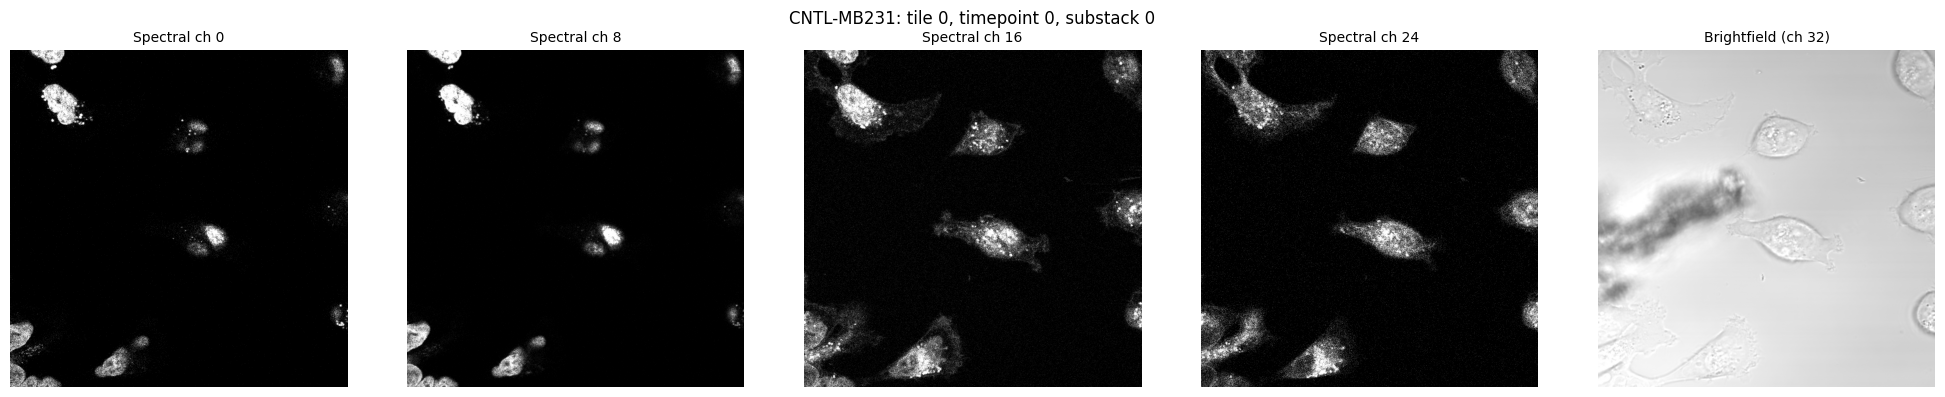

In [10]:
# Read tile 0, timepoint 0 — gives us a list of 2 "pages" (substacks)
with TiffFile(LSM_PATH) as tif:
    series = tif.series[0]
    pages = series[0, 0]  # tile=0, time=0
    frame = np.stack([p.asarray() for p in pages], axis=0)  # (2, 33, 1024, 1024)

# Use substack 0 for now (we'll investigate the difference in section 4)
img = frame[0]  # (33, 1024, 1024)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
channels_to_show = [0, 8, 16, 24, 32]
titles = ["Spectral ch 0", "Spectral ch 8", "Spectral ch 16", "Spectral ch 24", "Brightfield (ch 32)"]

for ax, ch, title in zip(axes, channels_to_show, titles):
    ax.imshow(img[ch], cmap="gray", vmin=0, vmax=np.percentile(img[ch], 99))
    ax.set_title(title, fontsize=10)
    ax.axis("off")

plt.suptitle("CNTL-MB231: tile 0, timepoint 0, substack 0", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Which substack to use?

Each tile/timepoint gives us 2 copies of the image (substacks). Let's check if they're different.

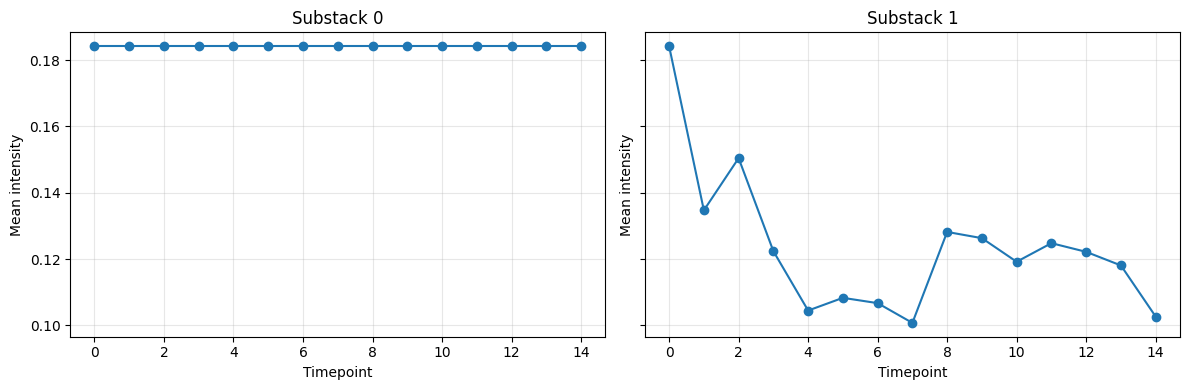

In [13]:
# Mean intensity of spectral channel 0 over time, for each substack
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

with TiffFile(LSM_PATH) as tif:
    series = tif.series[0]
    for ss, ax in enumerate(axes):
        means = []
        for t in range(series.shape[1]):
            pages = series[0, t]
            frame = np.stack([p.asarray() for p in pages], axis=0)
            means.append(frame[ss, 0].mean())
        ax.plot(means, "o-")
        ax.set_title(f"Substack {ss}")
        ax.set_xlabel("Timepoint")
        ax.set_ylabel("Mean intensity")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Substack 0 is flat: it's a static reference, same image at every timepoint
# Substack 1 changes over time: this is the actual time-lapse recording
# Conclusion: we should use substack 1